# Data2001 - Assignment 1: Group 59

## Members:

1. SID: 520447042
2. SID: 530483933
3. SID:
4. SID: 

# Task 1:

In [281]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker
from matplotlib.ticker import FormatStrFormatter
import warnings
warnings.filterwarnings('ignore')

## Task 1.1: Load CSV File

In [282]:
# Read in CSV and assign a name to the Series:
region = pd.read_csv("data/Region_summary_ New_South_ Wales_STE_1.csv")

## Task 1.2: Data Cleaning

### 1.2.1 Explore Raw Dataframe 

In [283]:
# Check DataFrame structure and info:
print("Dataframe Information:")
print("Indices: \n\t", region.index)
print("Columns: \n\t", region.columns)
print("Shape: \n\t", region.shape)
print("Axes: \n\t", region.axes)
print("Data type: \n", region.dtypes)

Dataframe Information:
Indices: 
	 RangeIndex(start=0, stop=800, step=1)
Columns: 
	 Index(['Measure Code', 'Parent Description', 'Description', '2011', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
       '2025'],
      dtype='object')
Shape: 
	 (800, 15)
Axes: 
	 [RangeIndex(start=0, stop=800, step=1), Index(['Measure Code', 'Parent Description', 'Description', '2011', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
       '2025'],
      dtype='object')]
Data type: 
 Measure Code           object
Parent Description     object
Description            object
2011                  float64
2015                  float64
2016                  float64
2017                  float64
2018                  float64
2019                  float64
2020                  float64
2021                  float64
2022                  float64
2023                  float64
2024                  float64
2025                  floa

### 1.2.2 Reformat data into long format

In [284]:
# Convert data into long format
# Where Year and Value have their own respecive columns.
region_long = region.melt(
    id_vars=["Measure Code", "Parent Description", "Description"], var_name="Year",value_name="Value"
)

#cast year to integer and Value to float 
region_long['Year'] = pd.to_numeric(region_long['Year'], errors='coerce').astype('int64')
region_long['Value'] = pd.to_numeric(region_long['Value'], errors='coerce')

### 1.2.3 Clean the Raw Data:

In [285]:
count_non_missing = region_long.groupby("Year")["Value"].count()
total_rows = region_long.groupby("Year")["Value"].size()

missing = total_rows - count_non_missing
print("Number of missing entries per year:\n",missing)

Number of missing entries per year:
 Year
2011    541
2015    780
2016    343
2017    752
2018    675
2019    530
2020    509
2021    108
2022    507
2023    593
2024    591
2025    797
Name: Value, dtype: int64


In [286]:
#Check for Missing values:
# 6726 missing values
print(region_long.isna().sum())

Measure Code             0
Parent Description       0
Description              0
Year                     0
Value                 6726
dtype: int64


In [287]:
#Check if there are any duplicates 
print(region_long.duplicated().sum())

0


In [288]:
# Drop rows with missing values
# Missing values represent unavailable data, not zero population which is why rows with missing values were removed for analysis.
region_long_clean = region_long.dropna(subset=["Value"], ignore_index=True) # drop the rows with missing values
region_long_clean.name="NSW Regions"

In [289]:
print(region_long_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2874 entries, 0 to 2873
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Measure Code        2874 non-null   object 
 1   Parent Description  2874 non-null   object 
 2   Description         2874 non-null   object 
 3   Year                2874 non-null   int64  
 4   Value               2874 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 112.4+ KB
None


In [290]:
print(region_long_clean.isna().sum())

Measure Code          0
Parent Description    0
Description           0
Year                  0
Value                 0
dtype: int64


### 1.2.4 Explore Cleaned Dataframe

In [291]:
# Check DataFrame structure and info:
print("Dataframe Information - Clean:")
print("name: \n\t",region_long_clean.name)
print("Indices: \n\t", region_long_clean.index)
print("Columns: \n\t", region_long_clean.columns.tolist())
print("Shape: \n\t", region_long_clean.shape)
print("Axes: \n\t", region_long_clean.axes)
print("Data type: \n", region_long_clean.dtypes)

Dataframe Information - Clean:
name: 
	 NSW Regions
Indices: 
	 RangeIndex(start=0, stop=2874, step=1)
Columns: 
	 ['Measure Code', 'Parent Description', 'Description', 'Year', 'Value']
Shape: 
	 (2874, 5)
Axes: 
	 [RangeIndex(start=0, stop=2874, step=1), Index(['Measure Code', 'Parent Description', 'Description', 'Year', 'Value'], dtype='object')]
Data type: 
 Measure Code           object
Parent Description     object
Description            object
Year                    int64
Value                 float64
dtype: object


In [292]:
region_long_clean.sample(10)

,Measure Code,Parent Description,Description,Year,Value
1935,LF_2,Labour force status - Persons aged 15 years an...,In the labour force (no.),2021,3874012.0
2196,ERP_M_28,Estimated resident population - Males - year e...,Males - 35-39 years (%),2022,7.2
758,DWELLSTOCK_12,Estimated dwelling stock - as at June quarter,Total dwelling removals (no.),2017,4687.0
1832,DWELLSTOCK_11,Estimated dwelling stock - as at June quarter,Total dwelling additions (no.),2021,52559.0
2825,CABEE_47,Number of businesses by turnover - at 30 June,Number of businesses with turnover of $10m or ...,2024,18725.0
1158,LEED_24,Jobs in Australia - year ended 30 June,Number of employee jobs - total,2019,5703475.0
1439,GIFTS3,Gifts and donations - year ended 30 June,Median value of gift and donation deductions ($),2020,150.0
1693,ING_HEAP3,Closing the Gap Target 6 - People aged 25-34 y...,Total applicable population aged 25-34 years (...,2021,34703.0
2764,ERP_P_24,Estimated resident population - Persons - year...,Persons - 15-19 years (%),2024,6.1
422,EMP_IND_13,Industry of employment - Persons aged 15 years...,"Rental, hiring and real estate services (%)",2016,1.8


## Task 1.3: Derived Statistics - TODO

### Group member 1 SID: 520447042

#### Stat 1: Gender Job growth 2018-2022

In [294]:
#Grab subset of data from region
leed_data = region_long_clean[region_long_clean["Measure Code"].str.contains('LEED')].copy()

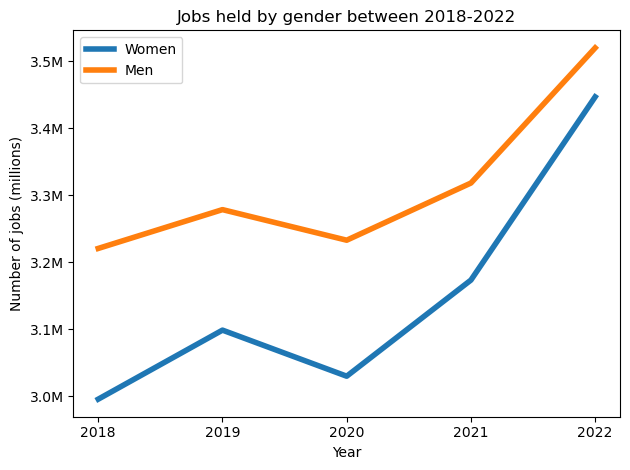

Results:
	Women's employment in NSW grew steadily from 2,995,986 jobs in 2018 to 3,446,628 in 2022. A 15.0% increase over the period. 
	Men consistently held more jobs across all years, growing from 3,220,689 to 3,519,659 . A 9.3% increase. 
	The gap of jobs held between genders narrowed from 224,703 to 73,031 jobs.



In [295]:
woman_jobs = leed_data[leed_data['Description'] == 'Number of jobs held by females'].groupby('Year')['Value'].sum()
men_jobs = leed_data[leed_data['Description'] == 'Number of jobs held by males'].groupby('Year')['Value'].sum()

woman_jobs.plot(label='Women', lw=4)
men_jobs.plot(label='Men', ax=plt.gca(), lw=4)

plt.title('Jobs held by gender between 2018-2022')
plt.xlabel('Year')
plt.ylabel('Number of jobs (millions)')

# convert y axis to millions
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%d'))
plt.gca().xaxis.set_ticks(woman_jobs.index)


plt.legend()
plt.tight_layout()
plt.show()


woman_perc = ((woman_jobs.iloc[-1] - woman_jobs.iloc[0]) / woman_jobs.iloc[0]) * 100
men_perc = ((men_jobs.iloc[-1] - men_jobs.iloc[0]) / men_jobs.iloc[0]) * 100
gap_start = men_jobs.iloc[0] - woman_jobs.iloc[0]
gap_end = men_jobs.iloc[-1] - woman_jobs.iloc[-1]


print("Results:")
print(f"\tWomen's employment in NSW grew steadily from {woman_jobs.iloc[0]:,.0f} jobs in {woman_jobs.index[0]} "
      f"to {woman_jobs.iloc[-1]:,.0f} in {woman_jobs.index[-1]}. A {woman_perc:.1f}% increase over the period. "
      f"\n\tMen consistently held more jobs across all years, growing from {men_jobs.iloc[0]:,.0f} to {men_jobs.iloc[-1]:,.0f} "
      f". A {men_perc:.1f}% increase. "
      f"\n\tThe gap of jobs held between genders {'narrowed' if gap_end < gap_start else 'widened'} "
      f"from {gap_start:,.0f} to {gap_end:,.0f} jobs.\n")


#### Stat 2: Economic Growth on Business entries and Exits

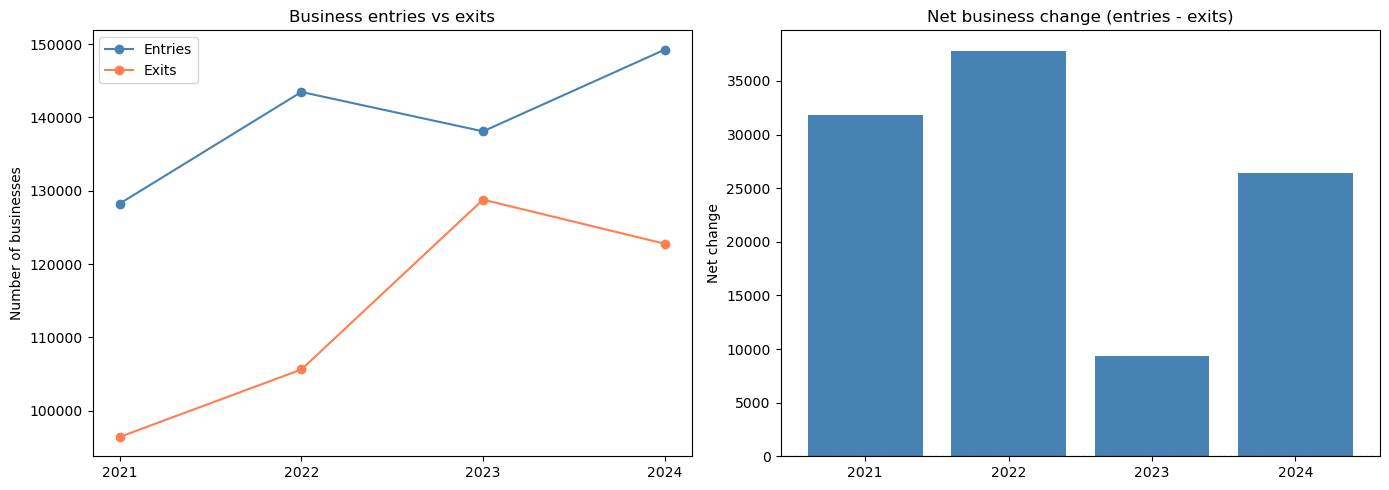

Results:
	The period of 2021-2022 brought new economy growth with +31807 companies in 2021 and +37829 in 2022.
	Although there was a dip in 2023 with -28520 less companies entering the economy, there was still positive growth with +9309 new companies
	entering the market in 2023. 2024 surpased 2023's growth with +17139 more new entry companies with a total of +26448 that year.



In [296]:
#Economic Growth on Business entries and Exits

entries = region_long_clean[region_long_clean['Measure Code'] == 'CABEE_10'].copy()
exits = region_long_clean[region_long_clean['Measure Code'] == 'CABEE_15'].copy()

for entry in [entries, exits]:
    entry['Year'] = pd.to_numeric(entry['Year'], errors='coerce')

entries = entries.sort_values('Year')
exits = exits.sort_values('Year')

common_years = set(entries['Year']).intersection(set(exits['Year']))
entries = entries[entries['Year'].isin(common_years)]
exits = exits[exits['Year'].isin(common_years)]

net = entries['Value'].values - exits['Value'].values
net_colors = ['steelblue' if x >= 0 else 'coral' for x in net]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(entries['Year'], entries['Value'], marker='o', color='steelblue', label='Entries')
axes[0].plot(exits['Year'], exits['Value'], marker='o', color='coral', label='Exits')
axes[0].set_title('Business entries vs exits')
axes[0].set_ylabel('Number of businesses')
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0].legend()


axes[1].bar(entries['Year'], net, color=net_colors)
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Net business change (entries - exits)')
axes[1].set_ylabel('Net change')
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()


grow = {}
for year, n in zip(entries['Year'], net):
    grow[int(year)] = f'{n:.0f}'

print("Results:")
print(f"\tThe period of 2021-2022 brought new economy growth with +{grow[2021]} companies in 2021 and +{grow[2022]} in 2022.\n" 
      f"\tAlthough there was a dip in 2023 with -{int(grow[2022])-int(grow[2023])} less companies entering the economy, there was still positive growth with +{grow[2023]} new companies\n"
      f"\tentering the market in 2023. 2024 surpased 2023's growth with +{int(grow[2024])-int(grow[2023])} more new entry companies with a total of +{grow[2024]} that year.\n")

#### Stat 3: Artificial vs Natural area coverage (2016-2019)

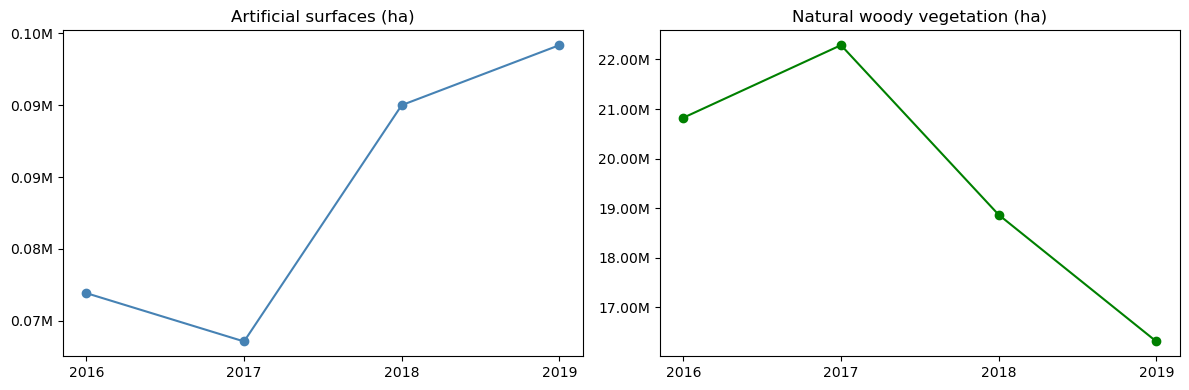

Results:
	Between 2016 and 2019 artificial surfaces increased by 22.4%, whereas natural woody vegetation changed by -21.7%.



In [308]:
# Artificial vs Natural area coverage (2016-2019)

artificial = region_long_clean[region_long_clean['Measure Code'] == 'LCOVER_1'].copy()
natural = region_long_clean[region_long_clean['Measure Code'] == 'LCOVER_4'].copy()

for entry in [artificial, natural]:
    entry['Year'] = pd.to_numeric(entry['Year'], errors='coerce')

artificial = artificial[(artificial['Year'] >= 2016) & (artificial['Year'] <= 2019)].sort_values('Year')
natural = natural[(natural['Year'] >= 2016) & (natural['Year'] <= 2019)].sort_values('Year')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(artificial['Year'], artificial['Value'], marker='o', color='steelblue')
axes[0].set_title('Artificial surfaces (ha)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

axes[1].plot(natural['Year'], natural['Value'], marker='o', color='green')
axes[1].set_title('Natural woody vegetation (ha)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

art_change = ((artificial['Value'].iloc[-1] - artificial['Value'].iloc[0]) / artificial['Value'].iloc[0]) * 100
nature_change = ((natural['Value'].iloc[-1] - natural['Value'].iloc[0]) / natural['Value'].iloc[0]) * 100

print("Results:")
print(f'\tBetween 2016 and 2019 artificial surfaces increased by {art_change:.1f}%, whereas natural woody vegetation changed by {nature_change:.1f}%.\n')

#### Stat 4: Gender Population across ages groups in 2022

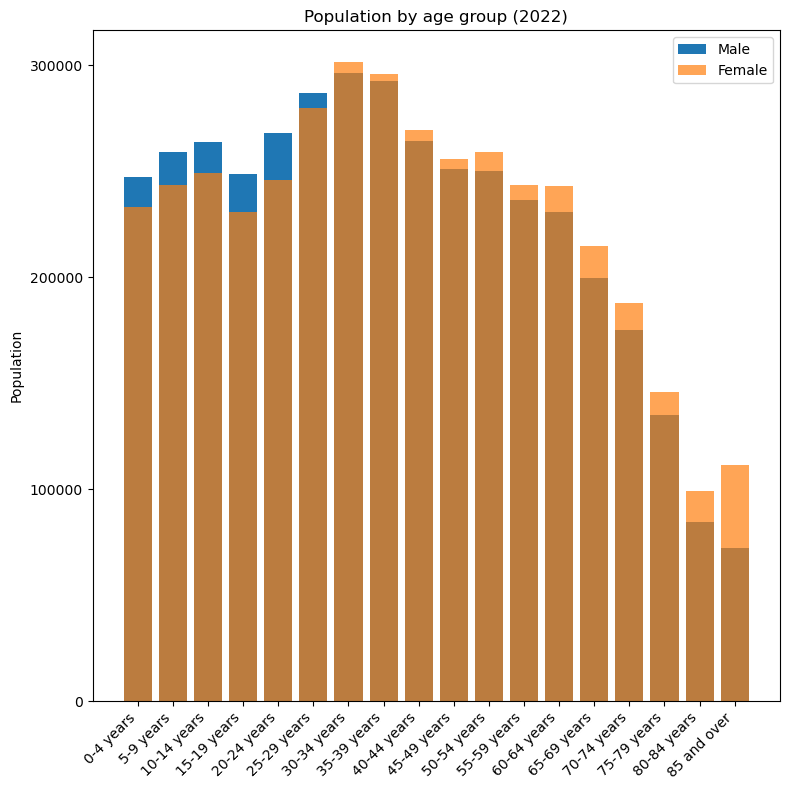

Results:
	During 2022 the population gender balance flips between the ages of 25-34.
	Between the ages 0-29 the average male population (262,138) is 6.2% higher than the average female population (246,924).
	From ages 30-85 the average female population (218,783) is 5.6% higher than the average male population (207,245).



In [300]:
# Gender Population across ages groups
year = 2022

m = males[males['Year'] == year]
f = females[females['Year'] == year]

fig, ax = plt.subplots(figsize=(8, 8))
ax.bar(m['age_group'], m['Value'], label='Male')
ax.bar(f['age_group'], f['Value'], label='Female', alpha=0.7)
ax.set_ylabel('Population')
ax.set_title(f'Population by age group ({year})')
ax.yaxis.set_major_locator(mticker.MultipleLocator(100000))
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# split the poplation of population divergence
#ages 0-29
young_m = m[m['Measure Code'].isin([f'ERP_M_{i}' for i in range(2, 8)])] 
young_f = f[f['Measure Code'].isin([f'ERP_F_{i}' for i in range(2, 8)])]

#ages 30-85+
older_m = m[m['Measure Code'].isin([f'ERP_M_{i}' for i in range(8, 20)])]  
older_f = f[f['Measure Code'].isin([f'ERP_F_{i}' for i in range(8, 20)])]

avg_young_m = young_m['Value'].mean()
avg_young_f = young_f['Value'].mean()
avg_older_m = older_m['Value'].mean()
avg_older_f = older_f['Value'].mean()

young_diff = ((avg_young_m - avg_young_f) / avg_young_f) * 100
older_diff = ((avg_older_f - avg_older_m) / avg_older_m) * 100

print("Results:")
print(f"\tDuring 2022 the population gender balance flips between the ages of 25-34.\n"
      f"\tBetween the ages 0-29 the average male population ({avg_young_m:,.0f}) is {young_diff:.1f}% higher than the average female population ({avg_young_f:,.0f}).")
print(f"\tFrom ages 30-85 the average female population ({avg_older_f:,.0f}) is {older_diff:.1f}% higher than the average male population ({avg_older_m:,.0f}).\n")


#### Stat 5: Commute distance to work by profession during 2016

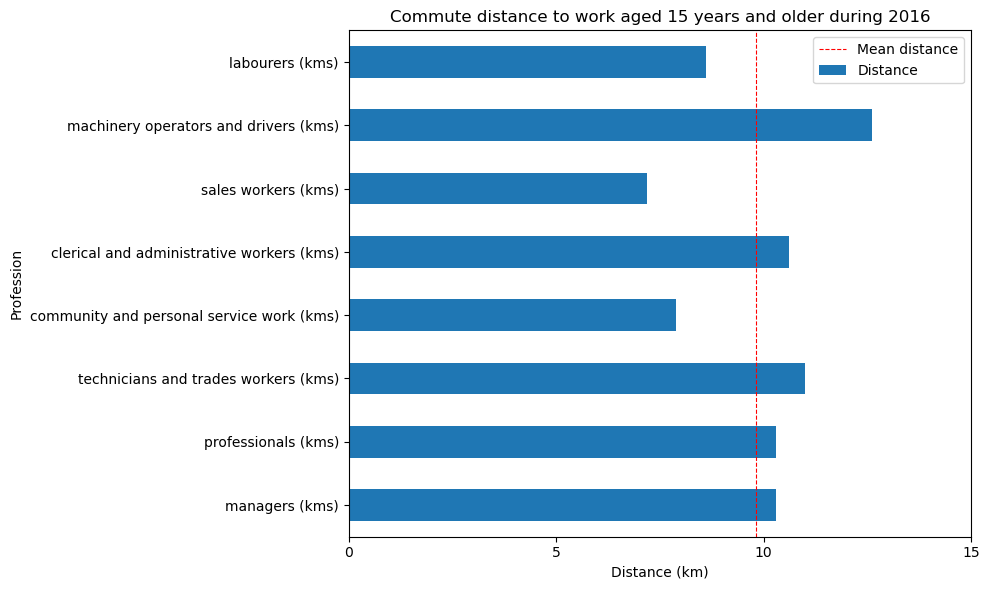

Results:
	The average commute time for all professions in 2016 was 9.8km.
	Machine Operators & drivers had the longest commute at 12.6km (28.4% above average)
	Sale workers had shortest commute at 7.2km (-26.6% below average)



In [301]:
# Comute Distance between professions
commute = region_long_clean[region_long_clean['Measure Code'].isin(['COMMUTE_18','COMMUTE_19','COMMUTE_20','COMMUTE_21',
                                                                     'COMMUTE_22','COMMUTE_23','COMMUTE_24','COMMUTE_25'])].copy()

commute = commute.set_index('Measure Code')
commute['label'] = commute['Description'].str.replace('Median commuting distance from place of usual residence - ', '', n=1)
commute.plot(kind='barh', x='label', y='Value', legend=False, figsize=(10, 6),label='Distance')
plt.axvline(x=commute['Value'].mean(), color='red', linewidth=0.8, linestyle='--', label='Mean distance')
plt.xticks(range(0, int(commute['Value'].max()) + 5, 5))
plt.title("Commute distance to work aged 15 years and older during 2016")
plt.legend()
plt.xlabel('Distance (km)')
plt.ylabel('Profession')
plt.tight_layout()
plt.show()

mean_dis = commute['Value'].mean()
most_km = commute.loc['COMMUTE_24', 'Value']
least_km = commute.loc['COMMUTE_23', 'Value']

print("Results:")
print(f"\tThe average commute time for all professions in 2016 was {mean_dis:.1f}km.\n"
      f"\tMachine Operators & drivers had the longest commute at {most_km:.1f}km ({(most_km/mean_dis)*100-100:.1f}% above average)\n"
      f"\tSale workers had shortest commute at {least_km:.1f}km ({(least_km/mean_dis)*100-100:.1f}% below average)\n")

### Group member 2 SID: 530483933

#### Stat 1: NSW median employee income growth (2018-2022) 

Median Employee Income ($) NSW:
 Year   Value
 2018 51411.0
 2019 53104.0
 2020 54989.0
 2021 57891.0
 2022 58972.0


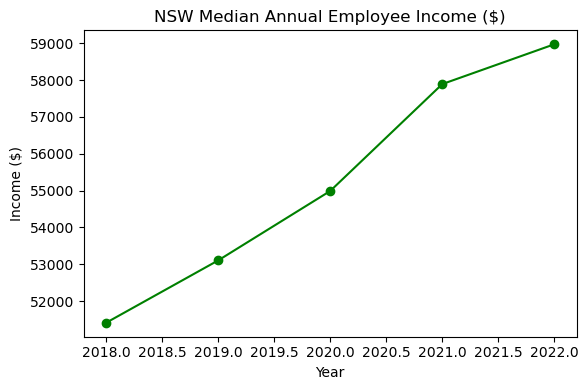


Income growth (2018-2022): 14.7%


In [302]:
income = region_long_clean[region_long_clean['Measure Code'] == 'INCOME_2'].copy() #Median employee income
income['Year'] = pd.to_numeric(income['Year'], errors='coerce')
income = income.sort_values('Year')
print('Median Employee Income ($) NSW:')
print(income[['Year', 'Value']].to_string(index=False)) 

income.plot(x='Year', y='Value', marker='o', legend=False, color='green', figsize=(6,4))
plt.title('NSW Median Annual Employee Income ($)')
plt.ylabel('Income ($)')
plt.tight_layout()
plt.show()

pct = ((income['Value'].iloc[-1] - income['Value'].iloc[0]) / income['Value'].iloc[0]) * 100
print(f'\nIncome growth ({int(income["Year"].iloc[0])}-{int(income["Year"].iloc[-1])}): {pct:.1f}%')

#### Stat 2: Median house transfer price vs median rent

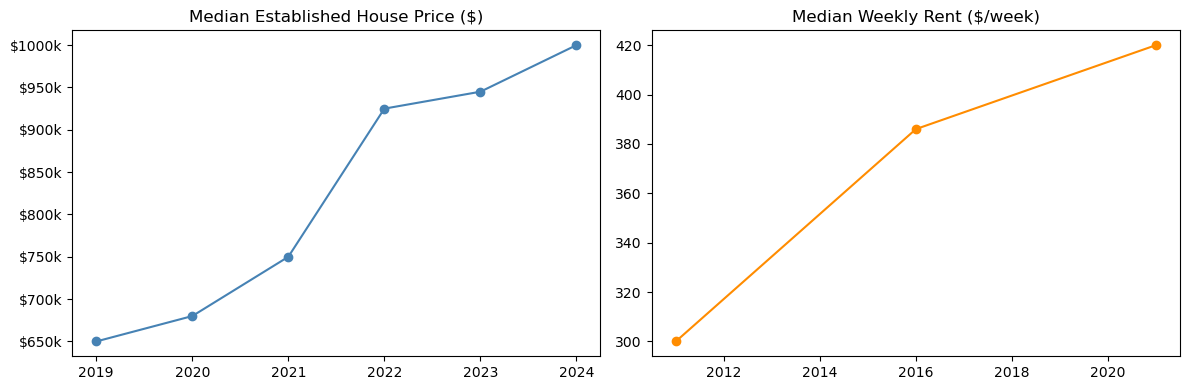

House price increase: 53.8%
Weekly rent increase: 40.0%


In [303]:
house = region_long_clean[region_long_clean['Measure Code'] == 'HOUSES_3'].copy() 
rent2 = region_long_clean[region_long_clean['Measure Code'] == 'RENT_4'].copy() 
for d in [house, rent2]: 
    d['Year'] = pd.to_numeric(d['Year'], errors='coerce') 
house = house.sort_values('Year') 
rent2 = rent2.sort_values('Year')

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(house['Year'], house['Value'], marker='o', color='steelblue')
axes[0].set_title('Median Established House Price ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))
axes[1].plot(rent2['Year'], rent2['Value'], marker='o', color='darkorange')
axes[1].set_title('Median Weekly Rent ($/week)')
plt.tight_layout()
plt.show()

h_chg = ((house['Value'].iloc[-1] - house['Value'].iloc[0]) / house['Value'].iloc[0]) * 100
print(f'House price increase: {h_chg:.1f}%')
r_chg = ((rent2['Value'].iloc[-1] - rent2['Value'].iloc[0]) / rent2['Value'].iloc[0]) * 100
print(f'Weekly rent increase: {r_chg:.1f}%')

#### Stat 3: Net overseas migration trend

Net Overseas Migration, NSW:
 Year    Value
 2021  -5940.0
 2022  69112.0
 2023 177100.0
 2024 137430.0


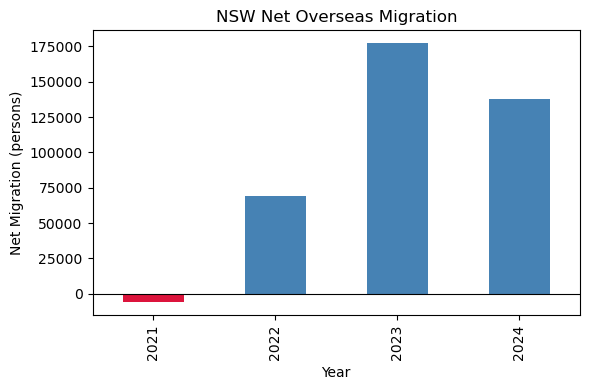

In [304]:
net_os = region_long_clean[region_long_clean['Measure Code'] == 'MIGRATION_7'].copy()
net_os['Year'] = pd.to_numeric(net_os['Year'], errors='coerce')
net_os = net_os.sort_values('Year')
print('Net Overseas Migration, NSW:')
print(net_os[['Year', 'Value']].to_string(index=False)) 

net_os.plot(x='Year', y='Value', kind='bar', legend=False, 
            color=['crimson' if v < 0 else 'steelblue' for v in net_os['Value']], figsize=(6,4))
plt.title('NSW Net Overseas Migration')
plt.ylabel('Net Migration (persons)')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

#### Stat 4: Private health insurance uptake overtime 

Persons with Private Health Insurance (NSW):
 Year     Value
 2017 2695252.0
 2018 2645559.0
 2019 2681569.0
 2020 2724637.0
 2021 2760933.0
 2022 2841811.0


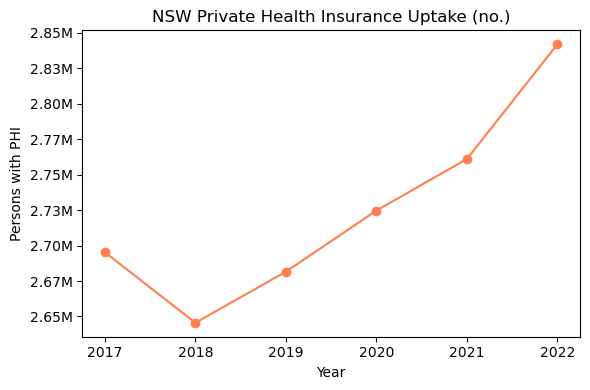

In [305]:
phi = region_long_clean[region_long_clean['Measure Code'] == 'PRIVATE_2'].copy()
phi['Year'] = pd.to_numeric(phi['Year'], errors='coerce')
phi = phi.sort_values('Year')
print('Persons with Private Health Insurance (NSW):')
print(phi[['Year', 'Value']].to_string(index=False)) 

phi.plot(x='Year', y='Value', marker='o', legend=False, color='coral', figsize=(6,4))
plt.title('NSW Private Health Insurance Uptake (no.)')
plt.ylabel('Persons with PHI')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.2f}M'))
plt.tight_layout()
plt.show()

#### Stat 5: Christianity decline and rise of no religion (Census years) 

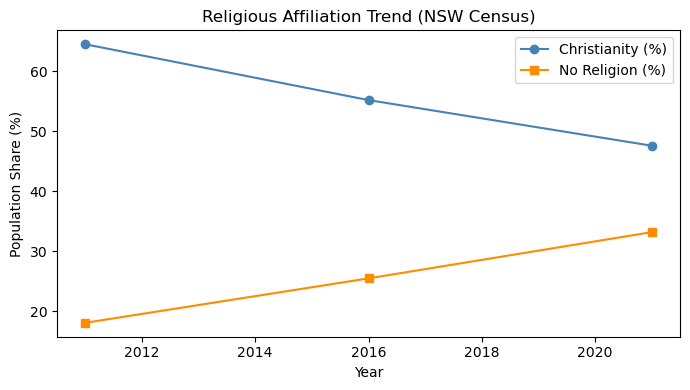

In [306]:
christ = region_long_clean[region_long_clean['Measure Code'] == 'CENSUS_16'].copy() #christianity %
norelig = region_long_clean[region_long_clean['Measure Code'] == 'CENSUS_40'].copy() #No religion %
for d in [christ, norelig]:
    d['Year'] = pd.to_numeric(d['Year'], errors='coerce')

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(christ['Year'],  christ['Value'],  marker='o', label='Christianity (%)',  color='steelblue')
ax.plot(norelig['Year'], norelig['Value'], marker='s', label='No Religion (%)', color='darkorange')
ax.set_title('Religious Affiliation Trend (NSW Census)')
ax.set_xlabel('Year')
ax.set_ylabel('Population Share (%)')
ax.legend()
plt.tight_layout()
plt.show()

### Group member 3 SID:

#### Stat 1:

#### Stat 2:

#### Stat 3:

#### Stat 4:

In [59]:
#### Stat 5:

### Group member 4 SID:

#### Stat 1:

#### Stat 2:

#### Stat 3:

#### Stat 4:

#### Stat 5:

# Task 2: API Data Collection - TO DO

## Task 2: Load in NSW Points of Interest API - TO DO

### Link to the API website: https://datasets.seed.nsw.gov.au/dataset/nsw-points-of-interest-poi

1. isolate an area box using longtitude and latitude
2. Find all POIs in chosen area
3. do analysis (check all these as i am doing this from memory)

In [ ]:
import requests 
import time 
import psycopg2
from psycopg2.extras import execute_values 

#configuration 
API_KEY = ""
API_BASE = ""
HEADERS = {"Authorization": f"apikey {API_KEY}", "Accept": "application/json"}

print("Libraries imported and API credentials set.")

## Task 2: Develop Function - TO DO

## Task 2: Build Loop - TO DO

## Task 2: Add results to Database - TO DO

# Task 3: Compute Scores - TO DO

# Task 4: Prepare Report - TO DO

# Task 5: Brief Conversation with Tutor - TO DO

# Deliverables - TO DO

1. PDF Report  - Google Doc: link in READ ME and : https://docs.google.com/document/d/1n2X06f8SsJrVs9xzTqE0d5J3EYx_cJwz28PFvmnBcf0/edit?usp=sharing
2. Juytper Notebook - THIS
3. Convo with tutor